# Meridian flip correction: rotating frames after flip cut 

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from heap.pre_cleaning import read_pff, cut_pkt_loss, spike_cut, read_pff_hk, cut_meridian_flip
from heap.correct_after_meridian_flip import divide_data_meridian_flip, rotate_after_flip

### Read pff files

In [10]:
data_path="../test_data/20251020/Gattini/pff/"
data_file=data_path+"start_2025-10-20T06:50:55Z.dp_ph1024.bpp_2.module_254.seqno_0.pff"
hk_file=data_path+"hk.pff"

data_path = Path(data_path).resolve()
if not data_path.exists():
    raise FileNotFoundError(f"Data directory not found: {data_path}")
else:
    print(data_path)

/Users/nik/Documents/PANOSETI/PANOSETI-High-Energy-Analysis-Pipeline/test_data/20251020/Gattini/pff


In [11]:
data, metadata = read_pff(data_file)
hk = read_pff_hk(hk_file)

Data read in, number of events:  24330


### Removing images with packet loss and around trigger rate spikes

In [12]:
data, timestamps = cut_pkt_loss(data, metadata)
data_spike_cut, timestamps_spike_cut = spike_cut(data, timestamps)

Number of Events with package loss:  42  ( 0.17 %)
Rate spikes at:  DatetimeIndex(['2025-10-20 03:11:55.799860001-07:00', '2025-10-20 04:30:55.799860001-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  8057  ( 33.17 %)


### Cutting out meridian flip (from pre_cleaning) for comparison

In [13]:
data_cut_mflip, timestamp_cut_mflip, start_mflip, end_mplip = cut_meridian_flip(data_spike_cut,timestamps_spike_cut,hk)

Start of meridian flip (local time):  2025-10-20 04:30:40.480678082-07:00 , End:  2025-10-20 04:33:48.265557288-07:00
Duration of meridian flip cut:  187.78487920761108
Number of cut out events from meridian flip:  163  ( 1.0 %)


### Dividing data into before and after flip cut (from correct_after_meridian_flip)

In [14]:
data_post_cuts, timestamps_post_cuts, start_mflip, end_mplip = divide_data_meridian_flip(data_spike_cut, timestamps_spike_cut, hk, time_after=60, plotting=False, path=None)

Start of meridian flip (local time):  2025-10-20 04:30:40.480678082-07:00 , End:  2025-10-20 04:33:48.265557288-07:00
Duration of meridian flip cut:  187.78487920761108
Number of cut out events from meridian flip:  163  ( 1.0 %)


### Rotating images after meridian flip (from correct_after_meridian_flip)

In [15]:
mer_flip_corr_data, mer_flip_corr_timestamps = rotate_after_flip(data_post_cuts, timestamps_post_cuts)

### Plotting post flip image from pre_cleaning and correct_after_meridian_flip functions 

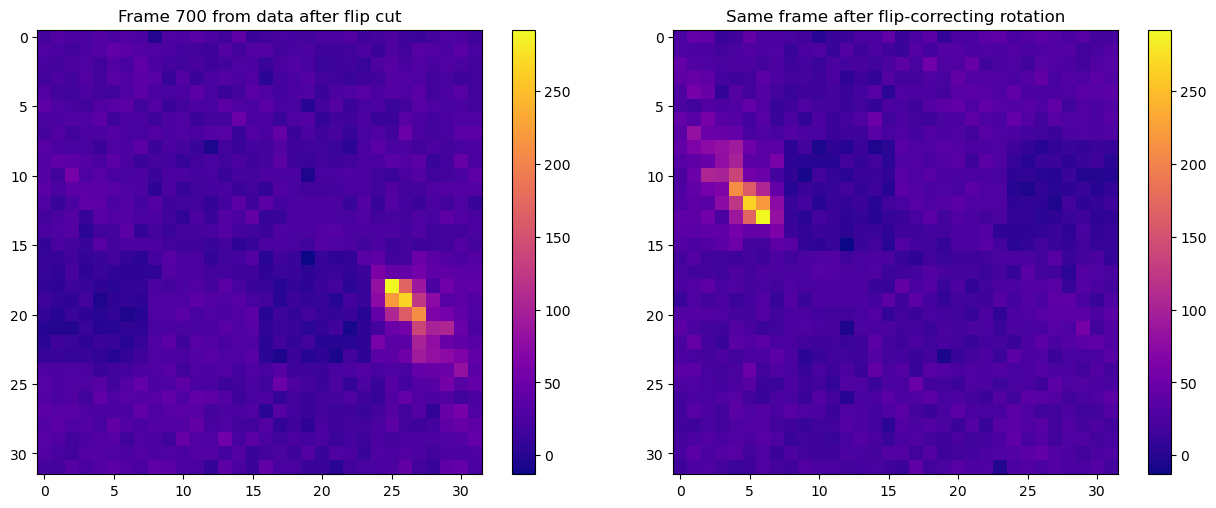

In [16]:
n_before = len(timestamps_post_cuts[0]) # Number of elements in the data before flip
nt_1 = 700 # Index in data_post_cuts[1]
nt_2 = n_before + nt_1 # Index in mer_flip_corr_data

fig, axes = plt.subplots(1, 2, figsize=(13, 5))  # 1 row, 2 columns

# First image
matrix1 = data_post_cuts[1][nt_1].reshape((32, 32))
im1 = axes[0].imshow(matrix1, cmap='plasma', interpolation='nearest')
axes[0].set_title("Frame "+str(nt_1)+" from data after flip cut")
plt.colorbar(im1, ax=axes[0])

# Second image
matrix2 = mer_flip_corr_data[nt_2].reshape((32, 32))
im2 = axes[1].imshow(matrix2, cmap='plasma', interpolation='nearest')
axes[1].set_title("Same frame after flip-correcting rotation")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()